In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("big_movement_predictions.csv")

In [3]:
options = {}

In [4]:
df['datetime'] = pd.to_datetime(df['ts_epoch'], unit='s').dt.tz_localize('UTC').dt.tz_convert('America/New_York')

In [5]:
import datetime

def dateStrike2opt(edate, callPut, strike, useSPX=False):
    # Try parsing the date with multiple formats
    for fmt in ("%m/%d/%Y", "%Y-%m-%d"):
        try:
            dtd = datetime.datetime.strptime(edate, fmt)
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"Date '{edate}' does not match expected formats.")
    
    blah = "O:SPY"
    if useSPX:
        blah = "O:SPXW"
    option = blah + dtd.strftime("%y%m%d") + callPut + str(strike).zfill(5) + "000"
    return option

In [6]:
from massive import RESTClient
import os
client = RESTClient(os.environ.get("polygon_api_key"))

def get_option(option_ticker, date):
    
    aggs = []
    for a in client.list_aggs(
    option_ticker,
    1,
    "minute",
    date,
    pd.to_datetime(date) + datetime.timedelta(days=1),
    adjusted="true",
    sort="asc",
    limit=500000,
    ):
        aggs.append(a)
    if len(aggs) == 0:
        return None
    option_df = pd.DataFrame(aggs)
    option_df['datetime'] = pd.to_datetime(option_df['timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
    return option_df

In [ ]:
test_df = df[df['pred_prob'] >= .33]
test_df = df[df['datetime'].dt.date > pd.to_datetime("2023-01-01").date()]

173763    0.005363
173764    0.003384
173765    0.002655
173766    0.002597
173767    0.002416
            ...   
432866    0.000243
432867    0.000243
432868    0.000243
432869    0.000243
432870    0.000243
Name: atr_from_open, Length: 259108, dtype: float64

In [ ]:
rets = []
missing_count = {}
for k, v in test_df.groupby('date'):
    day_miss_count = 0
    cooldown_timer = None
    for i in range(len(v)):
        row = v.iloc[i]
        if cooldown_timer is not None and row['datetime'] < cooldown_timer:
            continue
        if row['datetime'].time() > pd.to_datetime('15:28').time():
            continue
        if row['pred_prob'] >= .6:
            expected_move = row['atr_from_open'] * 5 * row['close']
            call_option = dateStrike2opt(row['date'], 'C', round(row['close']), 0)
            put_option = dateStrike2opt(row['date'], 'P', round(row['close']), 0)
            if call_option not in options:
                options[call_option] = get_option(call_option, row['date'])
            if put_option not in options:
                options[put_option] = get_option(put_option, row['date'])
            call_option_data = options[call_option]
            put_option_data = options[put_option]
            if call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty or put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty:
                print(f"Missing exit data for {call_option} or {put_option} on {row['datetime']}")
                missing_count[k] = missing_count.get(k, 0) + 1
                continue
            curr_trade = {
                'entry_time': row['datetime'],
                'call_entry_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not call_option_data.empty else None,
                'put_entry_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not put_option_data.empty else None,
                'call_exit_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not call_option_data.empty else None,
                'put_exit_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not put_option_data.empty else None,
            }
            trade_ret = {
            'call_return': (curr_trade['call_exit_price'] - curr_trade['call_entry_price']) / curr_trade['call_entry_price'] if curr_trade['call_entry_price'] is not None and curr_trade['call_exit_price'] is not None else None,
            'put_return': (curr_trade['put_exit_price'] - curr_trade['put_entry_price']) / curr_trade['put_entry_price'] if curr_trade['put_entry_price'] is not None and curr_trade['put_exit_price'] is not None else None,
            }
            print("total return: ", trade_ret['call_return'] + trade_ret['put_return'])

            cooldown_timer = row['datetime'] + pd.Timedelta(minutes=31)
            rets.append(curr_trade)
    

total return:  1.3518518518518516
total return:  1.5810810810810811
total return:  -0.04227941176470601
total return:  0.028043775649794767
total return:  -0.1567375886524823
total return:  1.245559845559846
total return:  -0.40749414519906335
total return:  -0.32896959459459457
total return:  -0.1939393939393939
total return:  0.3090794451450187
total return:  1.8062248995983934
total return:  2.0747474747474746
total return:  -0.4995748299319728
total return:  -0.4905814905814906
total return:  0.6696428571428573
total return:  -0.521531100478469
total return:  -0.5454545454545455
total return:  -0.6586206896551724
total return:  -0.24464886964886975
total return:  -0.5712477665276949
total return:  -0.8536585365853657
total return:  -0.1258305647840533
total return:  -0.38278388278388276
total return:  -0.4545045045045045
total return:  -0.18441558441558425
total return:  -0.2528701795702091
total return:  -0.2597402597402597
total return:  -0.0780494673112122
total return:  -0.8119

In [137]:
ret_df = pd.DataFrame(rets)
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price
0,2023-01-04 14:01:00-05:00,0.45,0.54,0.05,1.75
1,2023-01-04 14:32:00-05:00,0.30,0.37,1.05,0.03
2,2023-01-09 14:01:00-05:00,0.34,0.32,0.23,0.41
3,2023-01-23 14:47:00-05:00,0.34,0.43,0.65,0.05
4,2023-02-01 14:00:00-05:00,1.80,1.88,1.92,1.46
...,...,...,...,...,...
231,2025-12-04 14:24:00-05:00,0.43,0.34,0.83,0.04
232,2025-12-10 14:00:00-05:00,1.26,1.27,1.03,1.05
233,2025-12-10 14:31:00-05:00,1.09,1.00,1.93,0.22
234,2025-12-10 15:02:00-05:00,0.54,0.50,0.54,0.09


In [138]:
ret_df['call_return'] = (ret_df['call_exit_price'] - ret_df['call_entry_price']) / ret_df['call_entry_price']
ret_df['put_return'] = (ret_df['put_exit_price'] - ret_df['put_entry_price']) / ret_df['put_entry_price']
ret_df['total_return'] = ret_df['call_return'] + ret_df['put_return']
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price,call_return,put_return,total_return
0,2023-01-04 14:01:00-05:00,0.45,0.54,0.05,1.75,-0.888889,2.240741,1.351852
1,2023-01-04 14:32:00-05:00,0.30,0.37,1.05,0.03,2.500000,-0.918919,1.581081
2,2023-01-09 14:01:00-05:00,0.34,0.32,0.23,0.41,-0.323529,0.281250,-0.042279
3,2023-01-23 14:47:00-05:00,0.34,0.43,0.65,0.05,0.911765,-0.883721,0.028044
4,2023-02-01 14:00:00-05:00,1.80,1.88,1.92,1.46,0.066667,-0.223404,-0.156738
...,...,...,...,...,...,...,...,...
231,2025-12-04 14:24:00-05:00,0.43,0.34,0.83,0.04,0.930233,-0.882353,0.047880
232,2025-12-10 14:00:00-05:00,1.26,1.27,1.03,1.05,-0.182540,-0.173228,-0.355768
233,2025-12-10 14:31:00-05:00,1.09,1.00,1.93,0.22,0.770642,-0.780000,-0.009358
234,2025-12-10 15:02:00-05:00,0.54,0.50,0.54,0.09,0.000000,-0.820000,-0.820000


In [139]:
ret_df['price_of_entry'] = ret_df['call_entry_price'] + ret_df['put_entry_price']
ret_df[['price_of_entry', 'total_return']].corr()

,price_of_entry,total_return
price_of_entry,1.000000,0.018087
total_return,0.018087,1.000000


In [140]:
df_sorted = ret_df.sort_values('total_return', ascending=False)

top_5 = df_sorted.head(int(len(df_sorted) * 0.05))  # top 5%
print("Contribution of top 5% trades:",
      top_5['total_return'].sum() / df_sorted['total_return'].sum())


Contribution of top 5% trades: 3.6959419596419356


In [141]:
ret_df['put_return'].mean()

np.float64(0.07340713180520837)

In [142]:
ret_df['put_return'].sum()

np.float64(17.324083106029175)

In [143]:
ret_df['call_return'].sum()

np.float64(-4.228442200104476)

In [144]:
ret_df['call_return'].mean()

np.float64(-0.01791712796654439)

In [145]:
ret_df['total_return'].mean()

np.float64(0.05549000383866401)

In [146]:
ret_df['total_return'].sum()

np.float64(13.095640905924705)

In [147]:
ret_df['total_return'].describe()

count    236.000000
mean       0.055490
std        1.268969
min       -1.384013
25%       -0.536271
50%       -0.225872
75%        0.187843
max       10.009220
Name: total_return, dtype: float64

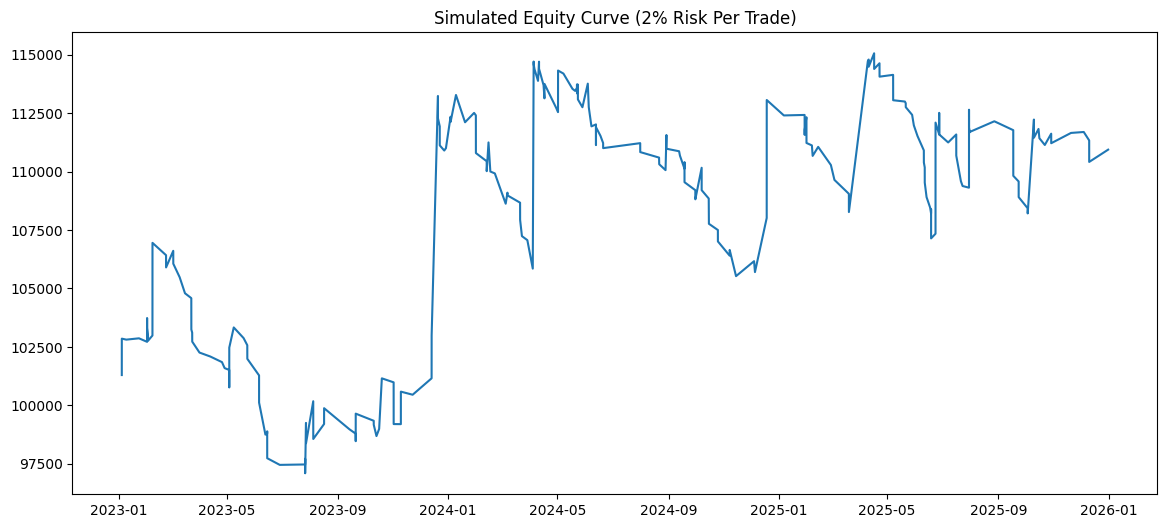

Final Capital: 110937.0
Total Return: 0.10936999999999997
Sharpe: 0.03733993958582871
Max Drawdown: -0.0921263008293518


In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ret_df = ret_df.copy()
ret_df['entry_time'] = pd.to_datetime(ret_df['entry_time'])
ret_df = ret_df.sort_values('entry_time').reset_index(drop=True)

# --- PARAMETERS ---
initial_capital = 100000
risk_fraction = 0.02   # 2% of capital per trade

capital = initial_capital
equity_curve = []

for i in range(len(ret_df)):
    row = ret_df.iloc[i]
    position_size = capital * risk_fraction
    call_entry_price = row['call_entry_price']
    put_entry_price = row['put_entry_price']
    call_contracts = int((position_size / 2) / (call_entry_price*100))
    put_contacts = int((position_size / 2) / (put_entry_price*100))
    call_ret =  100*call_contracts*(row['call_exit_price'] - call_entry_price)
    put_ret = 100*put_contacts*(row['put_exit_price'] - put_entry_price)
    pnl = call_ret + put_ret
    capital += pnl
    equity_curve.append(capital)

ret_df['equity'] = equity_curve

# --- Portfolio Returns ---
ret_df['portfolio_return'] = ret_df['equity'].pct_change().fillna(0)
ret_df['cum_return'] = ret_df['equity'] / initial_capital

# --- Metrics ---
mean_ret = ret_df['portfolio_return'].mean()
vol = ret_df['portfolio_return'].std()
sharpe = mean_ret / vol if vol != 0 else np.nan

rolling_max = ret_df['equity'].cummax()
drawdown = ret_df['equity'] / rolling_max - 1
max_dd = drawdown.min()

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(ret_df['entry_time'], ret_df['equity'])
plt.title("Simulated Equity Curve (2% Risk Per Trade)")
plt.show()

print("Final Capital:", capital)
print("Total Return:", capital/initial_capital - 1)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)


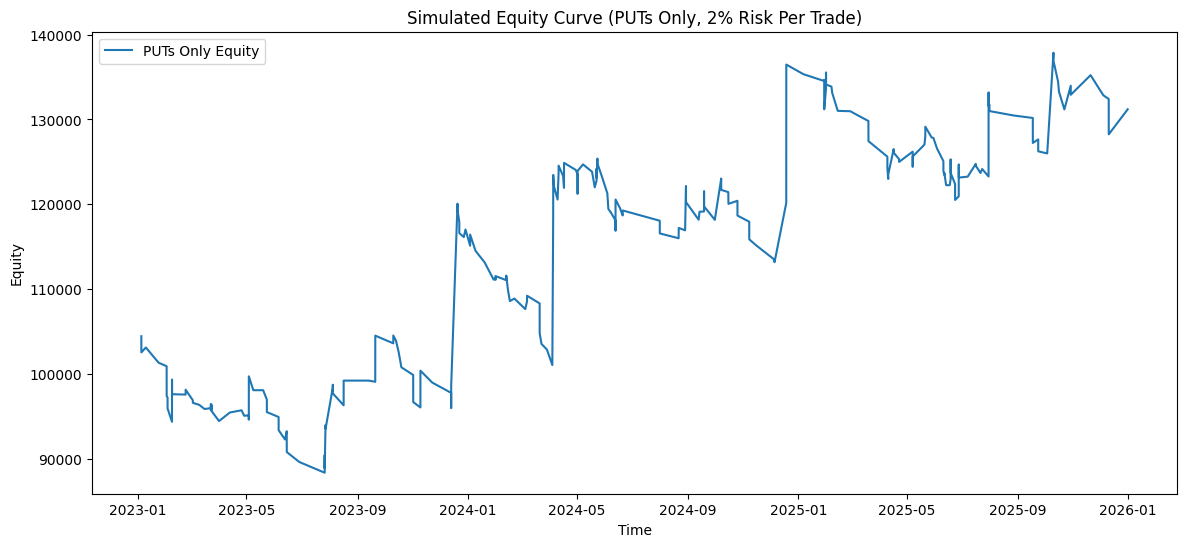

Final Capital: 131194.0
Total Return: 0.3119400000000001
Sharpe: 0.03733993958582871
Max Drawdown: -0.1582195203197868


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

put_ret_df = ret_df.copy()
put_ret_df['entry_time'] = pd.to_datetime(put_ret_df['entry_time'])
put_ret_df = put_ret_df.sort_values('entry_time').reset_index(drop=True)

# --- PARAMETERS ---
initial_capital = 100000
risk_fraction = 0.02   # 2% of capital per trade

capital = initial_capital
equity_curve = []

for i in range(len(ret_df)):
    row = ret_df.iloc[i]
    
    # --- Position sizing for PUTs only ---
    position_size = capital * risk_fraction
    put_entry_price = row['put_entry_price']
    put_contracts = int(position_size / (put_entry_price * 100))
    
    # --- PnL for PUTs only ---
    put_ret = 100 * put_contracts * (row['put_exit_price'] - put_entry_price)
    pnl = put_ret
    
    capital += pnl
    equity_curve.append(capital)

put_ret_df['equity'] = equity_curve

# --- Portfolio Returns ---
put_ret_df['portfolio_return'] = ret_df['equity'].pct_change().fillna(0)
put_ret_df['cum_return'] = ret_df['equity'] / initial_capital

# --- Metrics ---
mean_ret = put_ret_df['portfolio_return'].mean()
vol = put_ret_df['portfolio_return'].std()
sharpe = mean_ret / vol if vol != 0 else np.nan

rolling_max = put_ret_df['equity'].cummax()
drawdown = put_ret_df['equity'] / rolling_max - 1
max_dd = drawdown.min()

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(put_ret_df['entry_time'], put_ret_df['equity'], label='PUTs Only Equity')
plt.title("Simulated Equity Curve (PUTs Only, 2% Risk Per Trade)")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.legend()
plt.show()

print("Final Capital:", capital)
print("Total Return:", capital/initial_capital - 1)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

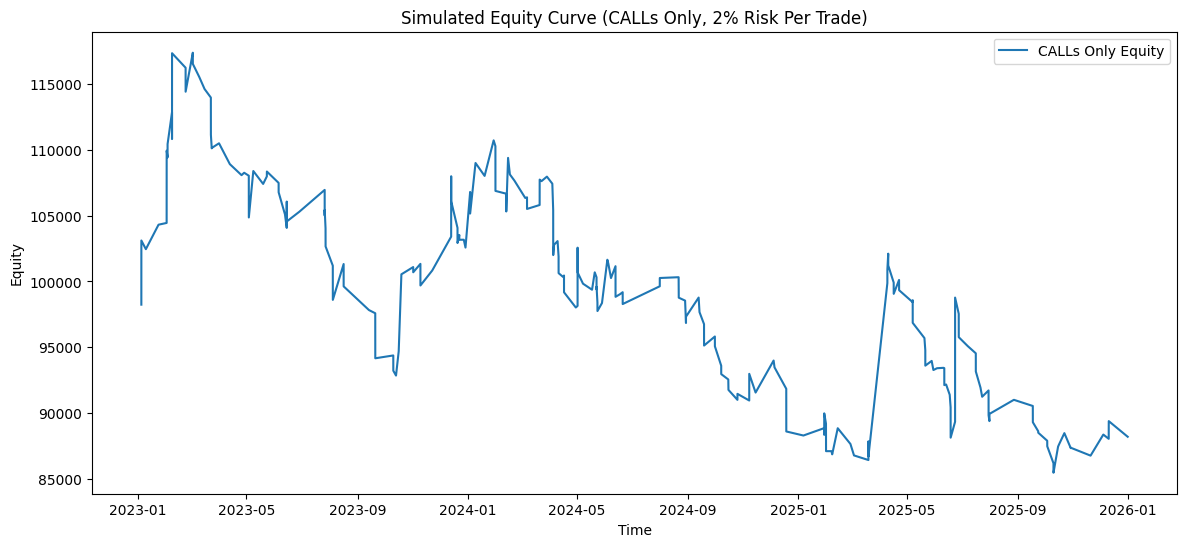

Final Capital: 88205.0
Total Return: -0.11795
Sharpe: -0.014824947891378042
Max Drawdown: -0.27179941555841436


In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

call_ret_df = ret_df.copy()
call_ret_df['entry_time'] = pd.to_datetime(call_ret_df['entry_time'])
call_ret_df = call_ret_df.sort_values('entry_time').reset_index(drop=True)

# --- PARAMETERS ---
initial_capital = 100000
risk_fraction = 0.02   # 2% of capital per trade

capital = initial_capital
equity_curve = []

for i in range(len(call_ret_df)):
    row = call_ret_df.iloc[i]
    
    # --- Position sizing for CALLs only ---
    position_size = capital * risk_fraction
    call_entry_price = row['call_entry_price']
    call_contracts = int(position_size / (call_entry_price * 100))
    
    # --- PnL for CALLs only ---
    call_ret = 100 * call_contracts * (row['call_exit_price'] - call_entry_price)
    pnl = call_ret
    
    capital += pnl
    equity_curve.append(capital)

call_ret_df['equity'] = equity_curve

# --- Portfolio Returns ---
call_ret_df['portfolio_return'] = call_ret_df['equity'].pct_change().fillna(0)
call_ret_df['cum_return'] = call_ret_df['equity'] / initial_capital

# --- Metrics ---
mean_ret = call_ret_df['portfolio_return'].mean()
vol = call_ret_df['portfolio_return'].std()
sharpe = mean_ret / vol if vol != 0 else np.nan

rolling_max = call_ret_df['equity'].cummax()
drawdown = call_ret_df['equity'] / rolling_max - 1
max_dd = drawdown.min()

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(call_ret_df['entry_time'], call_ret_df['equity'], label='CALLs Only Equity')
plt.title("Simulated Equity Curve (CALLs Only, 2% Risk Per Trade)")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.legend()
plt.show()

print("Final Capital:", capital)
print("Total Return:", capital/initial_capital - 1)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

In [149]:
ret_df['rolling_50'] = ret_df['portfolio_return'].rolling(50).sum()

In [150]:
wins = ret_df[ret_df['total_return'] > 0]['total_return']
losses = ret_df[ret_df['total_return'] <= 0]['total_return']

win_rate = len(wins) / len(ret_df)
avg_win = wins.mean()
avg_loss = losses.mean()

expectancy = win_rate * avg_win + (1 - win_rate) * avg_loss

print(win_rate, avg_win, avg_loss, expectancy)


0.3220338983050847 1.1646790396540587 -0.47137478817364836 0.05549000383866409


In [135]:
ret_df.columns

Index(['entry_time', 'call_entry_price', 'put_entry_price', 'call_exit_price',
       'put_exit_price', 'call_return', 'put_return', 'total_return',
       'price_of_entry', 'equity', 'portfolio_return', 'cum_return',
       'rolling_50'],
      dtype='object')